# Testing the Barnes-Hut Based Optimization for t-SNE Alpha Parameter

This implementation introduces a Barnes-Hut (BH) approximation to optimize the degree-of-freedom parameter (alpha) in t-SNE. The method leverages quad/oct-tree-based space partitioning to accelerate gradient computations for large datasets, significantly reducing the computational complexity from 
$$
\mathcal{O}(n^2) \text{ to } \mathcal{O}(n \log n)
$$


**Purpose:**

The Barnes-Hut approach aims to efficiently compute the gradient of the t-SNE loss function (KL divergence) with respect to alpha, allowing faster optimization for large datasets without sacrificing much accuracy.

**Rationale:**

By partitioning the data space into a hierarchical tree structure, distant points can be approximated as a single summary node, reducing the number of pairwise computations. This makes the method scalable for high-dimensional data embedding tasks.

**Implementation Details:**

Gradient Computation:
* A quad-tree structure (QuadTree) is built for the embedding, and a function estimate_negative_gradient_bh computes the negative gradient using the tree-based approximation.
* For each point, nearby points are treated individually, while distant points are approximated using aggregated statistics from the tree nodes.
* The gradient with respect to alpha is computed using a recursive function _estimate_negative_gradient_single.

Alpha Update:
* The gradient of the KL divergence with respect to alpha is calculated using the precomputed distances and affinities.
* The alpha value is updated iteratively by subtracting the product of the learning rate (alpha_lr) and the computed gradient.

Tree-Based Partitioning:
* A quad-tree implementation divides the embedding space into hierarchical regions, storing center-of-mass and bounding box information for efficient gradient estimation.
* Nodes are recursively split when more granularity is needed for local computations.

Cython Acceleration:
* Core computational routines, such as gradient estimation and quad-tree operations, are implemented in Cython to maximize performance.
* Parallelization is achieved using prange, allowing multi-threaded execution for large datasets.

**Advantages:**

* Efficiency: The Barnes-Hut method dramatically reduces computational cost, making it feasible to optimize alpha for datasets with thousands of points.
* Scalability: The hierarchical approximation scales well with increasing data size.
* Integration: Directly integrates with the t-SNE optimization pipeline, leveraging efficient tree-based algorithms.

**Drawbacks**

* Approximation Accuracy: The use of approximations may lead to less precise gradient calculations, particularly for datasets with closely clustered points.
* Complexity: The implementation is more complex than exact gradient methods, requiring careful memory management and tree-building routines.
* Dependence on Parameters: Performance depends on hyperparameters such as the Barnes-Hut theta (balance between speed and accuracy) and the number of threads.

In [ ]:
from sklearn.datasets import make_swiss_roll
import importlib
import multiprocessing

from cython_tsne_utils import quad_tree
from cython_tsne_utils import tsne_bh as custom_bh

from python_tsne_utils import utils

importlib.reload(utils)
importlib.reload(custom_bh)

In [2]:
num_threads = multiprocessing.cpu_count()   # Number of threads to use
print(f"Number of threads: {num_threads}")

Number of threads: 16


## Swiss Roll with 500 data points

In [3]:
X, color = make_swiss_roll(n_samples=500, noise=0)

### Initial alpha = 1

In [4]:
test_alpha = float(1)

In [5]:
tsne_result_1_opt_with_bh = utils.tsne_with_dof_optimisation(
    X=X,
    n_iter=500,
    initial_alpha=test_alpha,
    alpha_lr=0.1,
    dataset_name="Swiss Roll",
    optimise_for_alpha="bh",
    verbose=True,
    num_threads=num_threads
    
)

Initializing the t-SNE embedding...
Computing the affinity matrix...
Performing the PCA initialization...
Initializing the t-SNE embedding...
Performing the early exaggeration fase with exaggeration = 12 and learning rate = 41.666666666666664 for 250 iterations...
Running optimization for 500 iterations...
Optimizing with Barnes-Hut...
Iteration 0 out of 500 done
Current KL divergence: 1.9522480095090113
Current alpha: 1.0082423951238555
Current alpha gradient: -0.08242395123855459
-----------------------------------
Iteration 1 out of 500 done
Current KL divergence: 1.5210359759543426
Current alpha: 1.0314767537132465
Current alpha gradient: -0.2323435858939095
-----------------------------------
Iteration 2 out of 500 done
Current KL divergence: 1.2076290839105326
Current alpha: 1.0641088442081863
Current alpha gradient: -0.3263209049493979
-----------------------------------
Iteration 3 out of 500 done
Current KL divergence: 0.9767335229410161
Current alpha: 1.1049174263931252
Curre

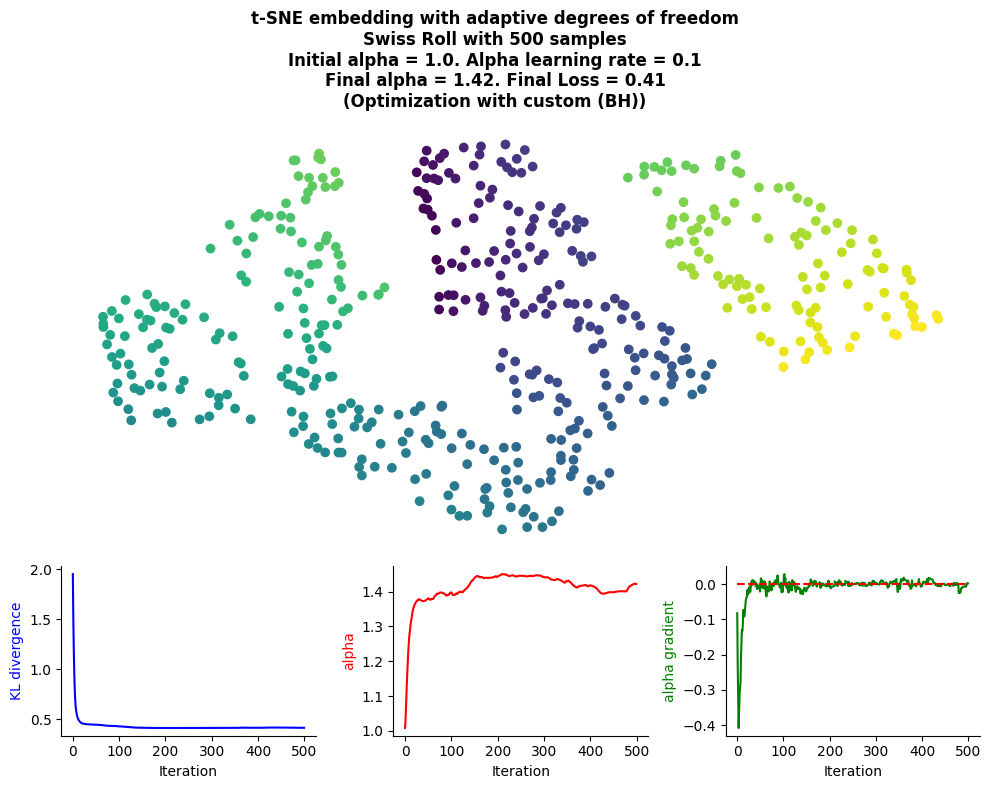

In [6]:
utils.plot_tsne_result(tsne_result_1_opt_with_bh, color, additional_title='(Optimization with custom (BH))')

In [7]:
tsne_result_1_gd = utils.tsne_with_dof_optimisation(X =X, n_iter=500, initial_alpha=test_alpha, alpha_lr=0.5, dataset_name="Swiss Roll", optimise_for_alpha='exact', verbose=True,)

Initializing the t-SNE embedding...
Computing the affinity matrix...
Performing the PCA initialization...
Initializing the t-SNE embedding...
Performing the early exaggeration fase with exaggeration = 12 and learning rate = 41.666666666666664 for 250 iterations...
Running optimization for 500 iterations...
Computing the exact gradients...
Iteration 0 out of 500 done
Current KL divergence: 1.9375542467055364
Current alpha: 1.0457229764748956
Current alpha gradient: -0.09144595294979138
-----------------------------------
Iteration 1 out of 500 done
Current KL divergence: 1.4484432698823095
Current alpha: 1.178880366998891
Current alpha gradient: -0.26631478104799083
-----------------------------------
Iteration 2 out of 500 done
Current KL divergence: 1.061200818347583
Current alpha: 1.359779994713751
Current alpha gradient: -0.36179925542972013
-----------------------------------
Iteration 3 out of 500 done
Current KL divergence: 0.7853699451145086
Current alpha: 1.5237138599871871
Cur

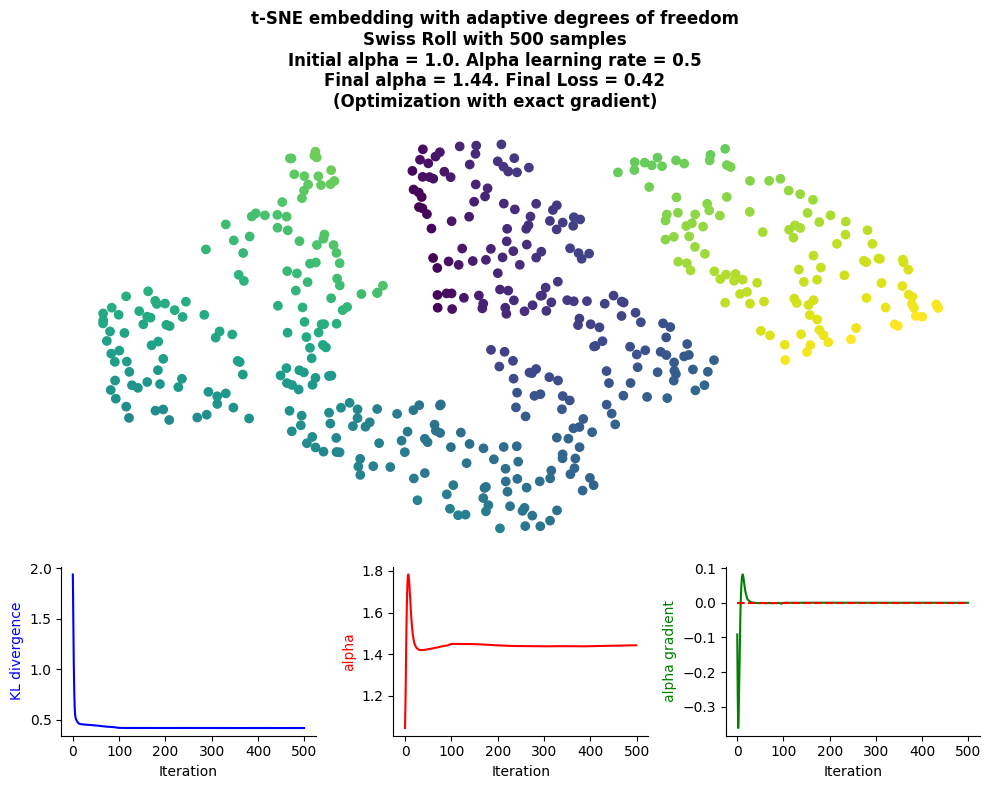

In [8]:
utils.plot_tsne_result(tsne_result_1_gd, color, additional_title='(Optimization with exact gradient)')

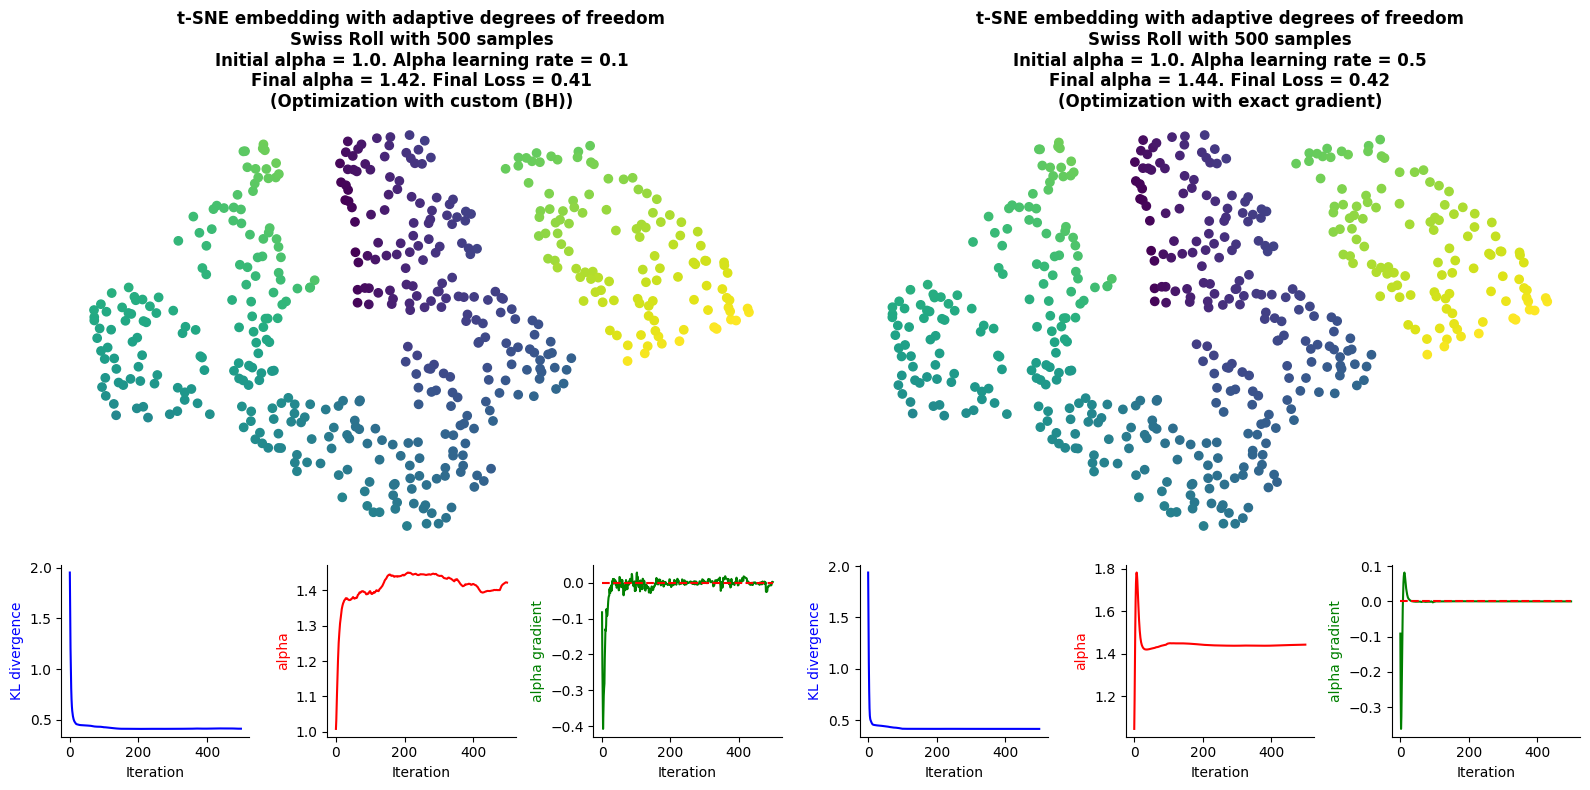

In [9]:
utils.plot_side_by_side(tsne_result_1_opt_with_bh, tsne_result_1_gd, color, additional_title_1='(Optimization with custom (BH))', additional_title_2='(Optimization with exact gradient)')

### Initial alpha = 5

In [10]:
test_alpha = float(5)

In [11]:
tsne_result_5_bh = utils.tsne_with_dof_optimisation(X =X, n_iter=500, initial_alpha=test_alpha, alpha_lr=0.5, dataset_name="Swiss Roll", optimise_for_alpha='bh', verbose=True, num_threads=num_threads)

Initializing the t-SNE embedding...
Computing the affinity matrix...
Performing the PCA initialization...
Initializing the t-SNE embedding...
Performing the early exaggeration fase with exaggeration = 12 and learning rate = 41.666666666666664 for 250 iterations...
Running optimization for 500 iterations...
Optimizing with Barnes-Hut...
Iteration 0 out of 500 done
Current KL divergence: 1.415074370610526
Current alpha: 5.004225388948916
Current alpha gradient: -0.008450777897831786
-----------------------------------
Iteration 1 out of 500 done
Current KL divergence: 0.9664710773864904
Current alpha: 5.0101298301250745
Current alpha gradient: -0.011808882352318358
-----------------------------------
Iteration 2 out of 500 done
Current KL divergence: 0.775847321268639
Current alpha: 5.006980903651693
Current alpha gradient: 0.006297852946763628
-----------------------------------
Iteration 3 out of 500 done
Current KL divergence: 0.6914030579599739
Current alpha: 4.990204197604778
Curren

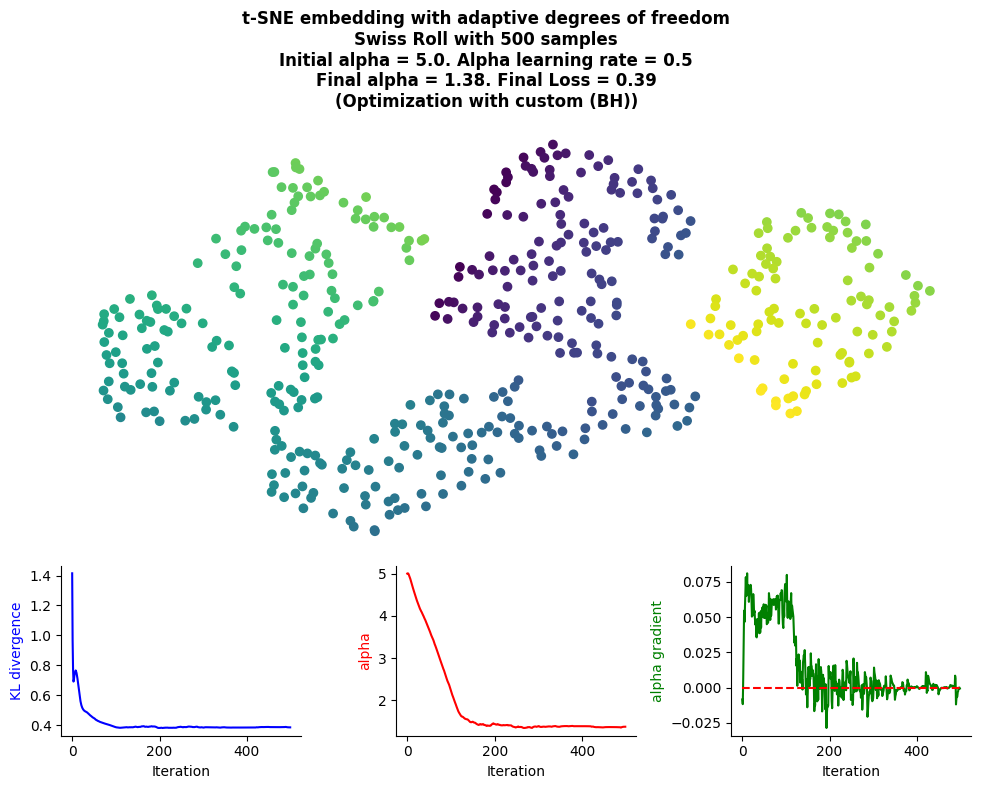

In [12]:
utils.plot_tsne_result(tsne_result_5_bh, color, additional_title='(Optimization with custom (BH))')

In [13]:
tsne_result_5_gd = utils.tsne_with_dof_optimisation(X =X, n_iter=500, initial_alpha=test_alpha, alpha_lr=0.5, dataset_name="Swiss Roll", optimise_for_alpha='exact', verbose=True,)

Initializing the t-SNE embedding...
Computing the affinity matrix...
Performing the PCA initialization...
Initializing the t-SNE embedding...
Performing the early exaggeration fase with exaggeration = 12 and learning rate = 41.666666666666664 for 250 iterations...
Running optimization for 500 iterations...
Computing the exact gradients...
Iteration 0 out of 500 done
Current KL divergence: 1.415037991789399
Current alpha: 5.005497951722115
Current alpha gradient: -0.01099590344423032
-----------------------------------
Iteration 1 out of 500 done
Current KL divergence: 0.9663977979177165
Current alpha: 5.015212837776433
Current alpha gradient: -0.01942977210863625
-----------------------------------
Iteration 2 out of 500 done
Current KL divergence: 0.7758755685536745
Current alpha: 5.021045906351315
Current alpha gradient: -0.011666137149763122
-----------------------------------
Iteration 3 out of 500 done
Current KL divergence: 0.6922010825107527
Current alpha: 5.016572033139477
Curr

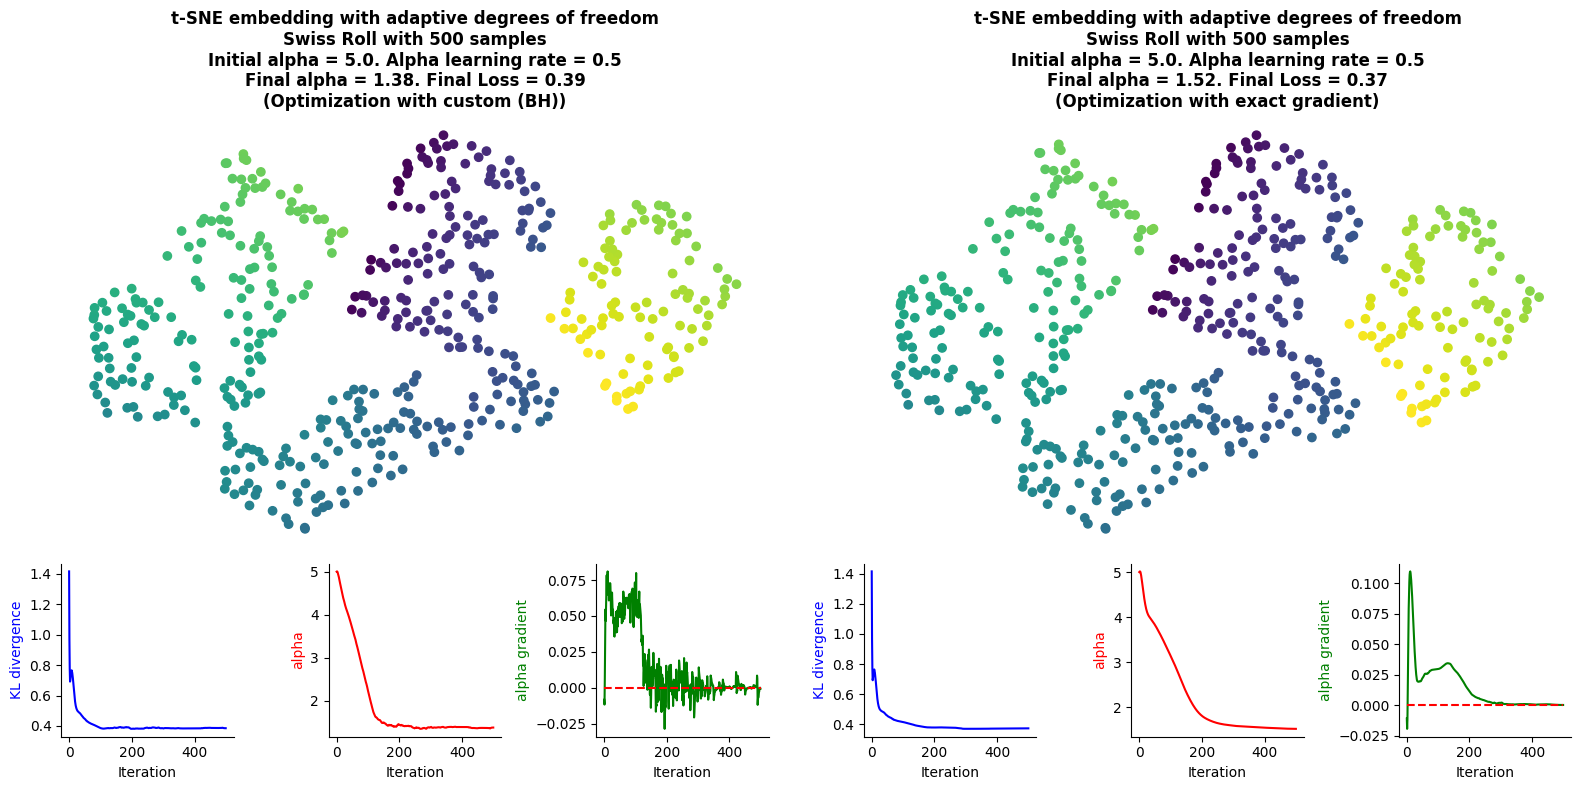

In [14]:
utils.plot_side_by_side(tsne_result_5_bh, tsne_result_5_gd, color, additional_title_1='(Optimization with custom (BH))', additional_title_2='(Optimization with exact gradient)')

## Swiss Roll with 10000 data points

In [15]:
X, color = make_swiss_roll(n_samples=10000, noise=0)

In [17]:
tsne_result_1_bh = utils.tsne_with_dof_optimisation(X =X, n_iter=500, initial_alpha=test_alpha, alpha_lr=0.5, dataset_name="Swiss Roll", optimise_for_alpha='bh', verbose=True, num_threads=num_threads)  

Initializing the t-SNE embedding...
Computing the affinity matrix...
Performing the PCA initialization...
Initializing the t-SNE embedding...
Performing the early exaggeration fase with exaggeration = 12 and learning rate = 833.3333333333334 for 250 iterations...
Running optimization for 500 iterations...
Optimizing with Barnes-Hut...
Iteration 0 out of 500 done
Current KL divergence: 1.8309725269397479
Current alpha: 5.0097976936023905
Current alpha gradient: -0.019595387204781357
-----------------------------------
Iteration 1 out of 500 done
Current KL divergence: 1.719923312286138
Current alpha: 5.018122326965783
Current alpha gradient: -0.01664926672678558
-----------------------------------
Iteration 2 out of 500 done
Current KL divergence: 1.6049371239225056
Current alpha: 5.025407703482807
Current alpha gradient: -0.01457075303404589
-----------------------------------
Iteration 3 out of 500 done
Current KL divergence: 1.4811690013722405
Current alpha: 5.030949215742376
Current

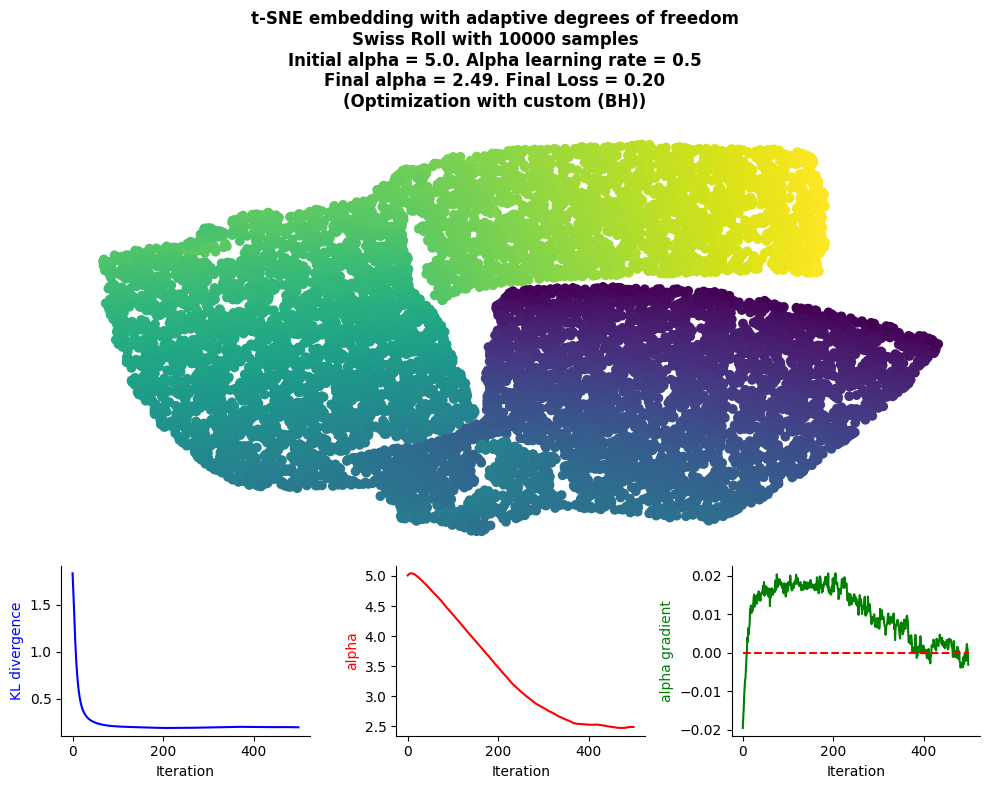

In [18]:
utils.plot_tsne_result(tsne_result_1_bh, color, additional_title='(Optimization with custom (BH))')

In [19]:
tsne_result_1_gd = utils.tsne_with_dof_optimisation(X =X, n_iter=500, initial_alpha=test_alpha, alpha_lr=0.5, dataset_name="Swiss Roll", optimise_for_alpha='exact', verbose=True,)

Initializing the t-SNE embedding...
Computing the affinity matrix...
Performing the PCA initialization...
Initializing the t-SNE embedding...
Performing the early exaggeration fase with exaggeration = 12 and learning rate = 833.3333333333334 for 250 iterations...
Running optimization for 500 iterations...
Computing the exact gradients...
Iteration 0 out of 500 done
Current KL divergence: 1.830501373503699
Current alpha: 5.020496405402067
Current alpha gradient: -0.0409928108041341
-----------------------------------
Iteration 1 out of 500 done
Current KL divergence: 1.7188584689857507
Current alpha: 5.042444713423785
Current alpha gradient: -0.043896616043434686
-----------------------------------
Iteration 2 out of 500 done
Current KL divergence: 1.6032488929287254
Current alpha: 5.06434827404029
Current alpha gradient: -0.04380712123301084
-----------------------------------
Iteration 3 out of 500 done
Current KL divergence: 1.4787969537559853
Current alpha: 5.086059569842765
Current

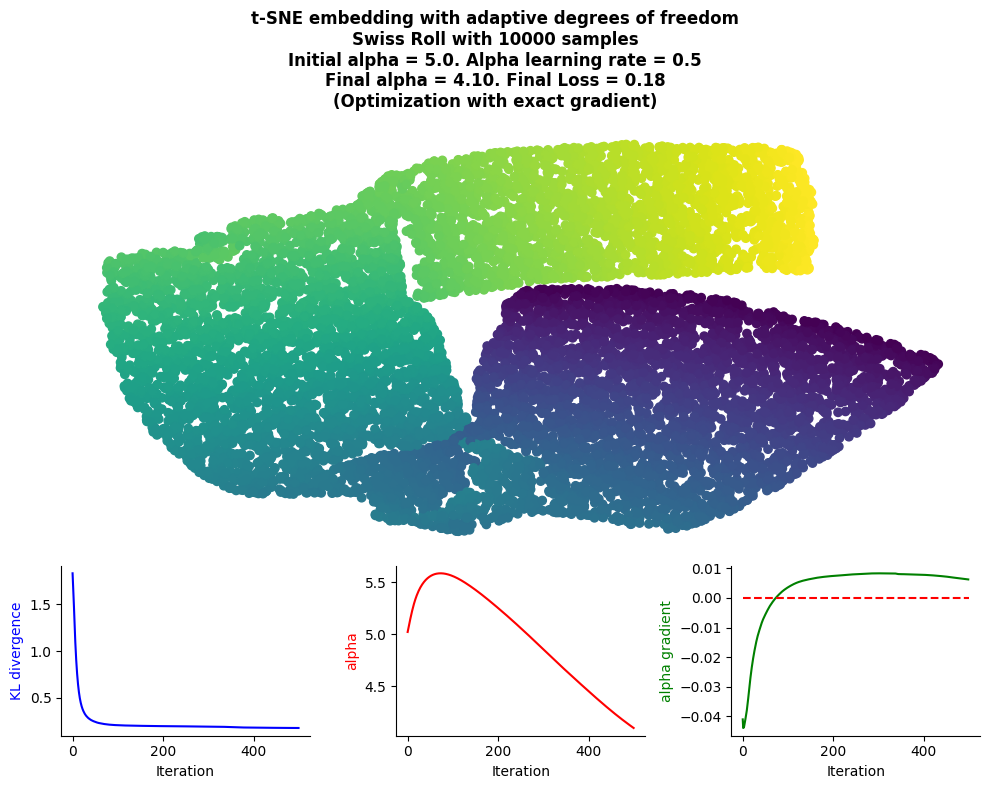

In [20]:
utils.plot_tsne_result(tsne_result_1_gd, color, additional_title='(Optimization with exact gradient)')

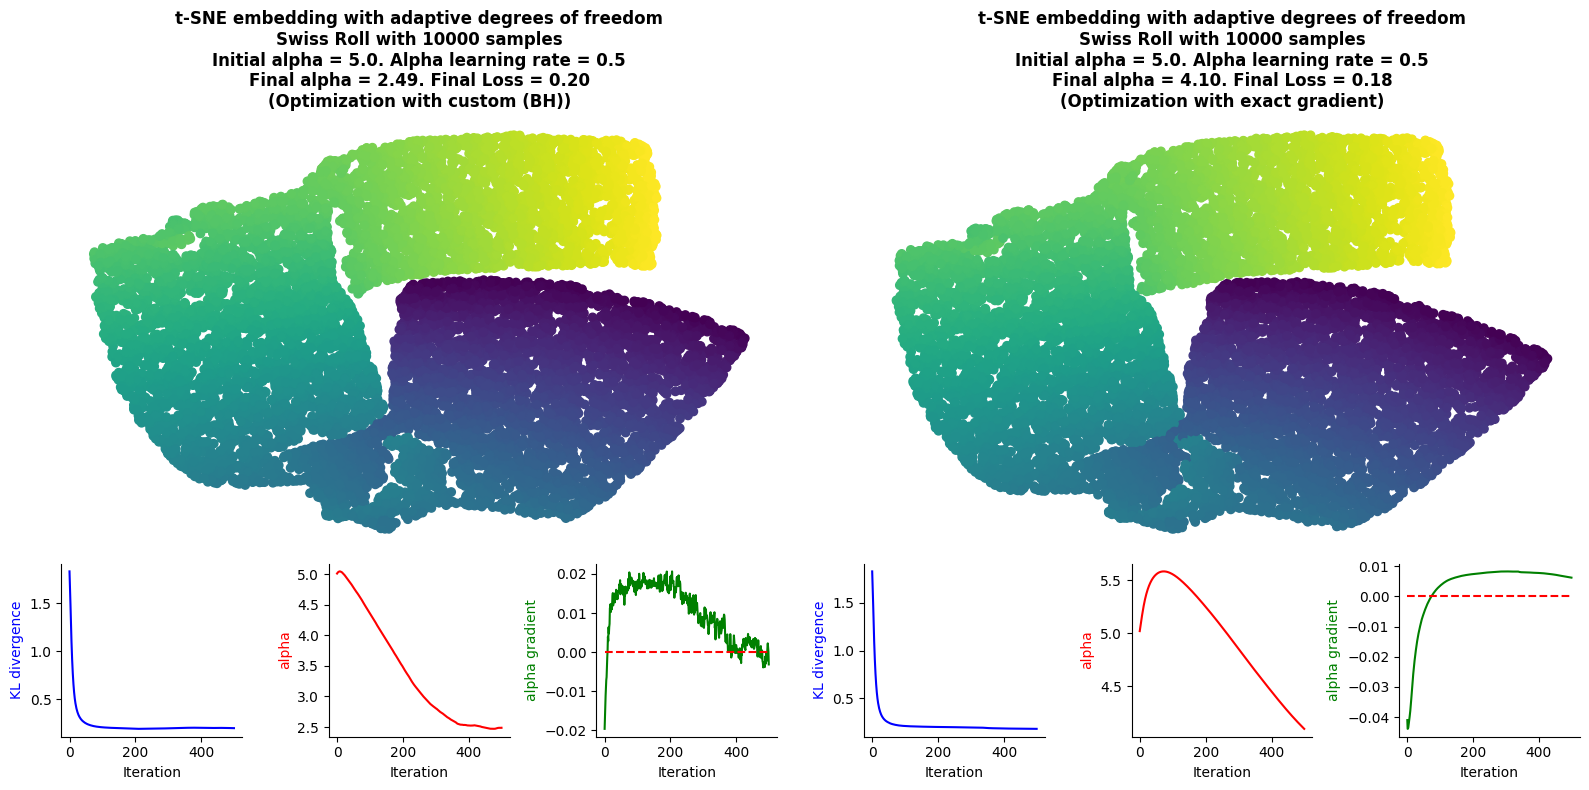

In [21]:
utils.plot_side_by_side(tsne_result_1_bh, tsne_result_1_gd, color, additional_title_1='(Optimization with custom (BH))', additional_title_2='(Optimization with exact gradient)')